In [166]:
import matplotlib
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from src.OrganoidMesh import OrganoidMesh
from src.mesh_analysis import *
from src.nonlocal_correlations import *
from src.cell_graph_functions import *

## Load organoid mesh, extract and filter marker fields

For illustration purposes we just treat a single organoid 

In [167]:
data_dir = '../NicoleData/20250929/fractal_output'

# choose one timepoint/well/round
timepoint = "day4p5"
zarr_name = "r0.zarr"
well = "B06"
round_name = "0_fused_zillum_registered"
organoid_id = 49  # 19 # example

# timepoint = "day4p5"
# zarr_name = "r0.zarr"
# well = "A06"
# round_name = "0_fused_zillum_registered"
# organoid_id = 31 # example

path = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_multi_annotated_class/{organoid_id}.vtp"


mesh = OrganoidMesh()
mesh.load_mesh_from_file(path)
mesh.align_with_pca()
_ = mesh.compute_spectral_coefficients(lmax=15)    # must populate m.eigvals, m.eigvecs

print(mesh.v.shape)

[Info] Eigen-decomposition not found. Computing now...
(18001, 3)


Extracting the fate marker intensity fields - the binary fields (0/1 indicating whether a cell is positive for a given expression) will be computed after coarse-graining.

In [168]:
t_hks = np.logspace(0, 2, num=50)
hks, hks_coeffs = compute_hks(mesh, t=t_hks) # HKS at time-scale comparable to cell size

In [ ]:
indices = [15750, 9350, 5200]   # villus

# indices = [9350]   # neck
# indices = [5200]   # crypt

arr = np.asarray(hks[:,0]-np.mean(hks[:,0]))
vmax = np.nanmax(np.abs(arr)) - 0.005

fig = go.Figure()

fig.add_trace(
    go.Mesh3d(
        x=mesh.v[:,0], y=mesh.v[:,1], z=mesh.v[:,2],
        i=mesh.f[:,0], j=mesh.f[:,1], k=mesh.f[:,2],
        intensity=hks[:,0]-np.mean(hks[:,0]),
        colorscale='RdBu_r',
        cmin=-vmax,
        cmax=+vmax,
        cmid=0,
    )
)


fig.add_trace(
    go.Scatter3d(
        x=mesh.v[indices,0],
        y=mesh.v[indices,1],
        z=mesh.v[indices,2],
        mode="markers",
        marker=dict(
            size=8,
            color='black',
            line=dict(color='white', width=2)
        ),
        showlegend=False
    )
)

fig.update_layout(
    scene = dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='rgba(0,0,0,0)',   # optional, makes background transparent
    )
)



fig.update_layout(height=550, width=750, title='HKS')
fig.show()

# fig.write_image("single_organoid_HKS_highlights.svg")


/tmp/ipykernel_32829/1813504218.py:53: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




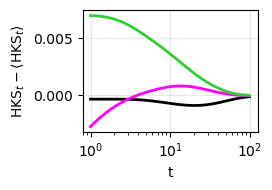

In [243]:
# plt.plot(t_hks, (hks[indices[0], :]-np.mean(hks,axis=0)))
# plt.plot(t_hks, (hks[indices[1], :]-np.mean(hks,axis=0)))
# plt.plot(t_hks, (hks[indices[2], :]-np.mean(hks,axis=0)))

# pick high-contrast colors vs RdBu_r:
colors = ["black", "magenta", "limegreen"]

plt.figure(figsize=(3,2))

for idx, c in zip(indices, colors):
    plt.plot(t_hks, (hks[idx, :]-np.mean(hks,axis=0)),
             color=c,
             linewidth=2,
             label=f"vertex {idx}")

plt.xscale('log')
plt.xlabel("t")
plt.ylabel(r"$\mathrm{HKS}_t - \langle \mathrm{HKS}_t \rangle$")
plt.grid(alpha=0.3)
# plt.legend()
# plt.title("Heat Kernel Signature vs time — selected vertices")

plt.tight_layout()

plt.savefig("hks_vertices.svg", format="svg")

plt.show()


## Coarse-grain to cell-level

To limit the computations needed for calculating correlations, we coarse-grain the vertex mesh, selecting the surface centroid of each cell. Additionally, we compute some quantities averaged over the surface area of each cell.

Note, for computing geodesic distances between the coarse-grained points, we still need the full mesh.

In [171]:
cell_center_vertices = mesh.get_centroid_vertices()
centroids, cell_areas, cell_weighted_fields, _ = mesh.compute_cell_statistics(hks)
markers_cell = mesh.marker_fields[cell_center_vertices, :]
_, bin_markers_cell = positive_indices_and_labels(markers_cell)

In [198]:
cell_graph = build_cell_graph(mesh)
print(mesh.marker_names)

from src.organoid_plotting import plot_organoid_graph


N = bin_markers_cell.shape[0]

colors = np.full(N, "darkgray", dtype=object)  # baseline

colors[bin_markers_cell[:,0] == 1] = "#1f77b4"   # blue
colors[bin_markers_cell[:,4] == 1] = "#2ca02c"   # green
colors[bin_markers_cell[:,8] == 1] = "#d62728"   # red
colors[bin_markers_cell[:,9] == 1] = "#9467bd"   # purple




fig = plot_organoid_graph(
    centroids,
    cell_graph,
    node_values=colors,   # <--- important
    node_size=5,
    edge_width=3.0,
)

fig.update_layout(
    scene_camera=dict(
        eye=dict(x=-0.8, y=-0.8, z=1.2)   # position of the camera
    )
)

fig.update_layout(
    scene = dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='rgba(0,0,0,0)',   # optional, makes background transparent
    )
)

legend_traces = [
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#1f77b4"),
        name="stem cell (LGR5+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#d62728"),
        name="enterochromaffin (Serotonin+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#2ca02c"),
        name="absorptive (AldoB+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#9467bd"),
        name="paneth (Lysozyme+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color='darkgray'),
        name="other",
        showlegend=True
    ),
]

for tr in legend_traces:
    fig.add_trace(tr)

fig.update_layout(height=550, width=750)
fig.write_image("organoid_graph.svg")
fig.show()


['LGR5', 'Chromogranin A', 'Cyclin D', 'Mucin 2', 'AldoB', 'Glucagon', 'Cyclin A', 'Agr2', 'Serotonin', 'Lysozyme']


/tmp/ipykernel_32829/142003412.py:84: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




In [235]:
center = v.mean(axis=0)
r = np.linalg.norm(v - center, axis=1)
r_norm = (r - r.min()) / (r.max() - r.min() + 1e-9)

fig = go.Figure()

fig.add_trace(
    go.Mesh3d(
        x=v[:,0], y=v[:,1], z=v[:,2],
        i=mesh.f[:,0], j=mesh.f[:,1], k=mesh.f[:,2],
        intensity=r_norm,
        colorscale=[
            [0.0, "rgb(230,220,255)"],  # light in center
            [1.0, "rgb(110,100,150)"],  # darker at edges
        ],
        showscale=False,
        opacity=0.7,
        flatshading=False,
        lighting=dict(
            ambient=0.3,
            diffuse=0.8,
            specular=0.4,
            roughness=0.4,
        ),
        lightposition=dict(x=0, y=0, z=1),
    )
)

fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode="data",
        camera=dict(projection=dict(type="orthographic")),
    )
)

fig.show()
